# find all the non-events for US-Canada

In [19]:
# all the imports you should need for this notebook
import xarray as xr
import metpy
import numpy as np
import pandas as pd
# Add colorbar with same height as plot
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import requests
from typing import Optional, Union, Literal
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import requests
import matplotlib.colors as mcolors
import matplotlib.patches as patches

# added by amy
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
from matplotlib.lines import Line2D
import shapely
from shapely.geometry import Polygon

import pandas as pd
from datetime import datetime, timedelta

from pathlib import Path

# make the basepath - change this to your local path
basepath = Path.home() / "extreme-weather-bench-paper" / ""
basepath = str(basepath) + "/"

import src.plots.plotting_utils as plot_utils  # noqa: E402


# ugly hack to load in our plotting scripts
# import sys  # noqa: E402

import extremeweatherbench as ewb

# Functions to read in and plot the data in Canada

In [20]:
# This is modified from the original code for CONUS to work with Canada LSR data
def extract_lsr_data_canada(date: pd.Timestamp) -> pd.DataFrame:
    """Pull the latest LSR data for a given date. We pull all reorts within 1 day. If date is none, we return all reports
    
    Args:
        date: A pandas Timestamp object.
    Returns:
        df: A pandas DataFrame containing the LSR data with columns lat, lon, report_type, time, and scale.
    """

    datafile = '/home/amy/CanadaLSRData_2020-2024.csv'

    # Read the CSV files with all columns to identify report types
    try:
        df = pd.read_csv(datafile, delimiter=',', engine='python', parse_dates=['Date/Time UTC'], date_format='%Y-%m-%d %H:%M:%S')
    except Exception as e:
        print(f'Error pulling hail data for {date}: {e}')
        return pd.DataFrame()

    # if date is none, presumably we want all reports
    if (date == None):
        return df

    # Filter the DataFrame for the specified date range
    spc_date = pd.Timestamp(date.year, date.month, date.day, 12, 00)  # Normalize to noon
    start_date = spc_date    
    end_date = spc_date + pd.Timedelta(days=1.0)
    df = df[(df['Date/Time UTC'] >= start_date) & (df['Date/Time UTC'] < end_date)]
    if len(df) == 0:
        #print(f'No LSR data found for {start_date} to {end_date}')
        return pd.DataFrame()
    return df


In [21]:
# helper functions to make the main plotting function cleaner
# helper function to convert a bounding box tuple to a shapely Polygon
def get_polygon_from_bounding_box(bounding_box):
    """Convert a bounding box tuple to a shapely Polygon."""
    if bounding_box is None:
        return None
    left_lon, right_lon, bot_lat, top_lat = bounding_box
    return Polygon(
        [
            (left_lon, bot_lat),
            (right_lon, bot_lat),
            (right_lon, top_lat),
            (left_lon, top_lat),
            (left_lon, bot_lat),
        ]
    )

# helper function to plot a polygon on a cartopy axis
def plot_polygon_outline(polygon, ax, color='yellow', alpha=0.5):
    """Plot a shapely Polygon on a Cartopy axis."""
    if polygon is None:
        return
    patch = patches.Polygon(
        polygon.exterior.coords,
        closed=True,
        facecolor='none',
        edgecolor=color,
        alpha=alpha,
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(patch)


# imported from figure 1 notebook and adjusted to plot reports
def plot_local_cases(left_lon, right_lon, bot_lat, top_lat, df, filename, plot_title, pph=None, sigsvr=None):
    """Plot the specified cases on a map of Canada.
    Args:
        left_lon: The left longitude of the bounding box.
        right_lon: The right longitude of the bounding box.
        bot_lat: The bottom latitude of the bounding box.
        top_lat: The top latitude of the bounding box.
        df: A pandas DataFrame containing the LSR data with columns 'Longitude', 'Latitude', and 'report_type'.
        filename: The name of the file to save the plot.
        plot_title: The title of the plot.
        pph: A 2D array of probabilities for plotting (optional).
        sigsvr: A 2D array of SIGSVR values for plotting (optional).
    Returns:
        None: The function saves the plot to the specified filename.
    """
    fig = plt.figure(figsize=(15, 10))
    #ax = plt.axes(projection=ccrs.LambertConformal())
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Add coastlines and gridlines
    ax.coastlines(zorder=10)
    ax.add_feature(cfeature.BORDERS, edgecolor='black', zorder=9)
    ax.add_feature(cfeature.STATES, edgecolor='grey', zorder=5)
    ax.add_feature(cfeature.LAND, edgecolor='black', zorder=3)
    ax.add_feature(cfeature.LAKES, edgecolor='black', facecolor='white', zorder=2)
    # plot the states
    #ax.add_feature(cfeature.OCEAN, zorder=10)
    #utils.remove_ocean_gridpoints(sigsvr)
    my_box = [left_lon, right_lon, bot_lat, top_lat]
    ax.set_extent(my_box, crs=ccrs.PlateCarree())

    # Add gridlines
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    if (pph is not None):
        # Plot the data using contourf
        levels = [0.01, .05,.15,.30,.45,.60,.75] 

        # Create a custom colormap that sets alpha=0 for values below 0.05
        cmap = plt.cm.viridis
        norm = mcolors.BoundaryNorm(levels, cmap.N)

        # Create the colormap with alpha=0 for values below 0.05
        # Create a mask for values below 0.05
        mask = np.ma.masked_less(pph, 0.01)
        cmap_with_alpha = plt.cm.viridis.copy()
        cmap_with_alpha.set_bad('none', alpha=0)  # Set masked values to transparent

        contour = ax.contour(pph.longitude, pph.latitude, mask, 
                            levels=levels, transform=ccrs.PlateCarree(),
                            cmap=cmap_with_alpha, norm=norm, extend='both', zorder=15)

        # Add colorbar
        cbar = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8, spacing='proportional')
        cbar.lines[0].set_linewidth(10.0)
        cbar.set_label('Probability')

    if (sigsvr is not None):
        masked_sigsvr = sigsvr.where(sigsvr >= 500)
        print(masked_sigsvr.max())
        im = masked_sigsvr.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Reds',
                        add_colorbar=False, vmin=0)
        cbar = fig.colorbar(im, label="Craven SigSvr (m³/s³)")
        cbar.set_label("Craven SigSvr (m³/s³)", size=14)
        cbar.ax.tick_params(labelsize=12)

    # Make sure reports are visible by increasing size and using a distinctive color
    # Convert string coordinates to float before plotting
    colors = {'tor': 'red','wind': 'blue', 'hail': 'black'}
    markers= {'tor': 'o', 'wind': 's', 'hail': '^'}  

    event_colors = {'non_tornadic_vortex': 'pink', 'unclassified_wind_damage': 'blue', 
                    'tornado_over_land': 'red', 'downburst': 'darkblue', 'tornado_over_water': 'lightcoral', 
                    'unclassified_visual_vortex': 'orange', 'nan': 'gray'}

    # Define zorder values to control plotting order (higher values appear on top)
    zorders = {'tor': 22, 'wind': 21, 'hail': 20}
    
    # Sort the dataframe by report type to ensure tornadoes are plotted last (on top)
    # Create a custom sort order where 'tor' comes last
    sort_order = {'hail': 0, 'wind': 1, 'tor': 2}
    sorted_df = df.copy()
    sorted_df['sort_key'] = sorted_df['report_type'].map(sort_order)
    
    # Group by report type and plot each group with its own color
    for report_type, group in sorted_df.sort_values('sort_key').groupby('report_type'):
        ax.scatter(group['Longitude'].astype(float), group['Latitude'].astype(float), 
                  color=colors.get(report_type, 'gray'), s=20, marker=markers.get(report_type), alpha=0.9,
                  transform=ccrs.PlateCarree(), label=f'{report_type.capitalize()} Reports', 
                  zorder=zorders.get(report_type, 10))

    # Count the number of reports for each type
    counts = df['report_type'].value_counts().to_dict()
    print(counts)

    # Create custom legend handles
    legend_elements = [
        Line2D([0], [0], marker=markers.get(label), color=colors[label], label=f'{label} (n={count})', markerfacecolor=colors[label], markersize=10)
        for label, count in counts.items()
    ]
    
    
     # Create a larger legend by specifying a larger font size in the prop dictionary
    ax.legend(handles=legend_elements, loc='upper left', framealpha=1, frameon=True, borderpad=0.5, handletextpad=0.8, handlelength=2.5)
    ax.set_title("")
    ax.set_title(plot_title, loc='left', fontsize=20)

    if (filename is not None):
        plt.savefig(filename, transparent=False, bbox_inches='tight', dpi=300)

# Load in the US data so we can compare across the border

In [22]:
def pull_lsr_data(date: pd.Timestamp) -> pd.DataFrame:
    """Pull the latest LSR data for a given date. A "date" for LSRs is considered the
    date starting at 12 UTC to the next day at 11:59 UTC.
    
    Args:
        date: A pandas Timestamp object.
    Returns:
        df: A pandas DataFrame containing the LSR data with columns lat, lon, report_type, time, and scale.
    """
    # Try the filtered URL first, if it fails, try without _filtered
    url = f"https://www.spc.noaa.gov/climo/reports/{date.strftime('%y%m%d')}_rpts_filtered.csv"
    # Check if the URL exists by attempting to open it
    response = requests.head(url)
    if date < pd.Timestamp('2004-02-29'):
        raise ValueError("LSR data before 2004-02-29 is not available in CSV format")
    if response.status_code == 404:
        # If the filtered URL doesn't exist, use the non-filtered version
        url = f"https://www.spc.noaa.gov/climo/reports/{date.strftime('%y%m%d')}_rpts.csv"
    # Read the CSV file with all columns to identify report types
    try:
        df = pd.read_csv(url, delimiter=',', engine='python', names=['Time','Scale','Location','County','State','Lat','Lon','Comments'])
    except Exception as e:
        print(f'Error pulling LSR data for {date}: {e}')
        return pd.DataFrame()
    if len(df) == 3:
        return pd.DataFrame()
    # Initialize report_type column
    df['report_type'] = None
    
    # Find rows with headers and mark subsequent rows with appropriate report type
    for i, row in df.iterrows():
        if 'F_Scale' in row.values:
            df.loc[i+1:, 'report_type'] = 'tor'
        elif 'Speed' in row.values:
            df.loc[i+1:, 'report_type'] = 'wind'
        elif 'Size' in row.values:
            df.loc[i+1:, 'report_type'] = 'hail'
    
    # Keep only necessary columns
    df = df[['Lat', 'Lon', 'report_type','Time', "Scale"]]
    # Remove rows that have 'Lat' in the 'Lat' column (these are header rows)
    df = df[df['Lat'] != 'Lat']
    time = pd.to_datetime(df['Time'], format='%H%M').dt.time
    df['Time'] = pd.to_datetime(date.strftime('%Y-%m-%d') + ' ' + time.astype(str))
    df = df.rename(columns={'Lat': 'lat', 'Lon': 'lon','Time':'time'})
    return df

In [23]:
# loop through all cases in US and Canada and find days with zero tornadoes and less than 10 hail reports. We ignore wind
# reports for now
bot_lat = 10
top_lat = 85
left_lon = -152
right_lon = -45

bounding_box = [left_lon, right_lon, bot_lat, top_lat]

# get the Canada data
can_data = extract_lsr_data_canada(date=None)  # Get all reports

potential_dates = []

# loop through all dates from 2020-2024
for date in pd.date_range('2020-01-01', '2024-12-31'):
    # # only search march-august
    # if (date.month < 3) or (date.month > 8):
    #     continue

    # grab the canada data for this date
    daily_can_data = extract_lsr_data_canada(date=date)  # Get all reports
    daily_us_data = pull_lsr_data(date)

    if (len(daily_can_data) == 0) and (len(daily_us_data) == 0):
        # print(f"{date.strftime('%Y-%m-%d')}: No reports")
        continue

    if (len(daily_us_data) > 0):
        # keep potential dates that have less than 10 hail reports and no tor reports
        wind_count = daily_us_data[daily_us_data['report_type'] == 'wind'].shape[0]
        hail_count = daily_us_data[daily_us_data['report_type'] == 'hail'].shape[0]
        tor_count = daily_us_data[daily_us_data['report_type'] == 'tor'].shape[0]

        if (tor_count == 0 and hail_count < 10):
            if (len(daily_can_data) == 0):
                print(f"{date.strftime('%Y-%m-%d')}: {wind_count} wind reports, {hail_count} hail reports, {tor_count} tor reports; No Canada reports")
                potential_dates.append(date)
            else:
                can_hail_count = daily_can_data[daily_can_data['report_type'] == 'hail'].shape[0]
                can_tor_count = daily_can_data[daily_can_data['report_type'] == 'tor'].shape[0]

                if (can_hail_count > 0) or (can_tor_count == 0):
                    print(f"{date.strftime('%Y-%m-%d')}: Canada reports {can_hail_count} hail reports, {can_tor_count} tor reports")
                    potential_dates.append(date)


2020-01-02: 2 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-01-03: 1 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-01-12: 3 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-01-15: 3 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-01-17: 1 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-01-24: 1 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-01-29: 1 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-02-01: 3 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-02-13: 13 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-02-18: 1 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-02-23: 1 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-02-24: 3 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-02-26: 4 wind reports, 0 hail reports, 0 tor reports; No Canada report

/tmp/ipykernel_3922254/3949641338.py:44: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(date.strftime('%Y-%m-%d') + ' ' + time.astype(str))


2020-03-10: 1 wind reports, 5 hail reports, 0 tor reports; No Canada reports
2020-03-11: 1 wind reports, 4 hail reports, 0 tor reports; No Canada reports
2020-03-14: 0 wind reports, 1 hail reports, 0 tor reports; No Canada reports
2020-03-20: 32 wind reports, 4 hail reports, 0 tor reports; No Canada reports
2020-03-22: 1 wind reports, 5 hail reports, 0 tor reports; No Canada reports
2020-03-23: 1 wind reports, 2 hail reports, 0 tor reports; No Canada reports
2020-03-29: 5 wind reports, 6 hail reports, 0 tor reports; No Canada reports
2020-04-02: 0 wind reports, 2 hail reports, 0 tor reports; No Canada reports
2020-04-03: 2 wind reports, 5 hail reports, 0 tor reports; No Canada reports
2020-04-04: 2 wind reports, 2 hail reports, 0 tor reports; No Canada reports
2020-04-15: 1 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-04-16: 1 wind reports, 0 hail reports, 0 tor reports; No Canada reports
2020-04-26: 19 wind reports, 6 hail reports, 0 tor reports; No Canada repor

/tmp/ipykernel_3922254/3949641338.py:44: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(date.strftime('%Y-%m-%d') + ' ' + time.astype(str))


2022-07-24: Canada reports 2 hail reports, 0 tor reports
2022-07-25: 78 wind reports, 4 hail reports, 0 tor reports; No Canada reports
2022-07-30: Canada reports 2 hail reports, 1 tor reports
2022-08-06: 36 wind reports, 2 hail reports, 0 tor reports; No Canada reports
2022-08-07: 36 wind reports, 7 hail reports, 0 tor reports; No Canada reports
2022-08-09: 54 wind reports, 6 hail reports, 0 tor reports; No Canada reports
2022-08-10: 82 wind reports, 1 hail reports, 0 tor reports; No Canada reports
2022-08-13: Canada reports 15 hail reports, 0 tor reports
2022-08-14: Canada reports 6 hail reports, 0 tor reports
2022-08-16: Canada reports 2 hail reports, 0 tor reports
2022-08-17: Canada reports 2 hail reports, 0 tor reports
2022-09-02: 20 wind reports, 6 hail reports, 0 tor reports; No Canada reports
2022-09-03: 22 wind reports, 1 hail reports, 0 tor reports; No Canada reports
2022-09-05: 1 wind reports, 3 hail reports, 0 tor reports; No Canada reports
2022-09-06: 6 wind reports, 0 hail

In [24]:
len(potential_dates)

365

/home/amy/extreme-weather-bench-paper/src/plots/plotting_utils.py:1319: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower left", fontsize=12)


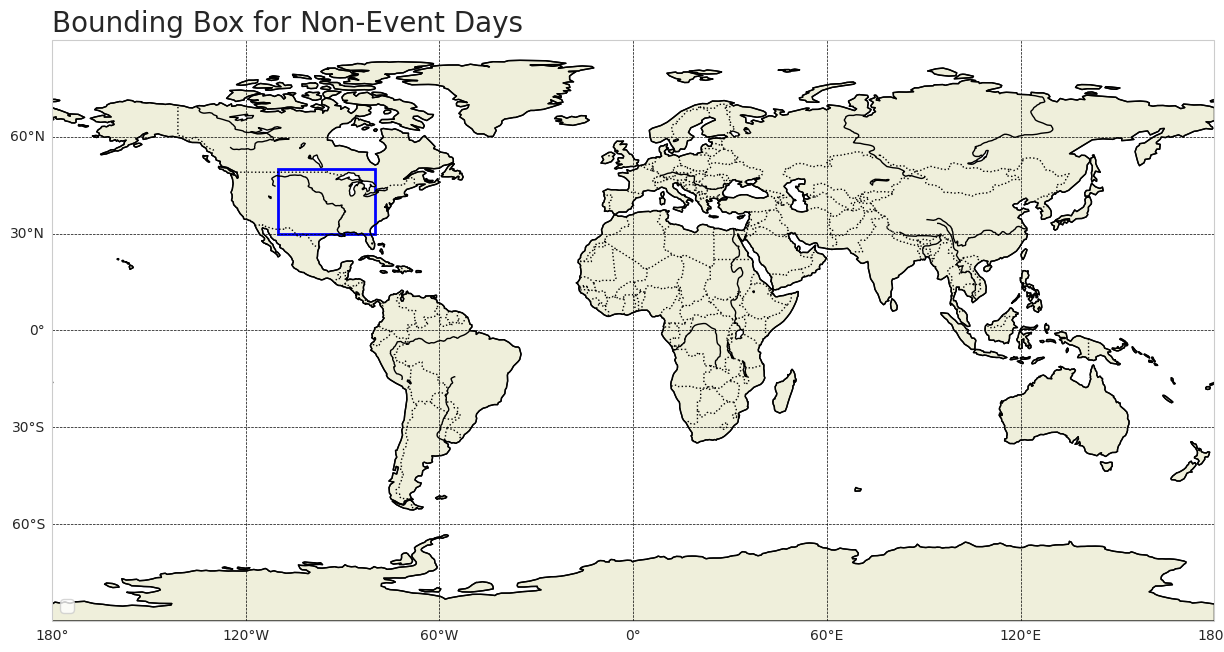

In [25]:
# plot the bounding box we will use for the non-event days
bounding_box = [250, 280, 30, 50]
bounding_box_polygon = get_polygon_from_bounding_box(bounding_box)

# plot North America
plot_utils.plot_boxes([bounding_box_polygon], [], title="Bounding Box for Non-Event Days")


In [34]:
# make the IndividualCase objects for all of our non-events
import datetime
from extremeweatherbench.cases import IndividualCase
from extremeweatherbench.regions import BoundingBoxRegion
import random

# randomly sample 30 dates from the potential dates
random_dates = random.sample(potential_dates, 30)

case_id = 8000
non_event_cases = []

for date in random_dates:
    # make the start/end match SPC
    start_date = date.replace(hour=12, minute=0, second=0, microsecond=0)
    end_date = (date + pd.Timedelta(days=1)).replace(hour=12, minute=0, second=0, microsecond=0)
    # coerce the timestamp back to a datetime object
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    severe_non_event = IndividualCase(
        case_id_number=case_id,
        title=f"{date.strftime('%Y-%m-%d')} Severe Convection Non-Event",
        start_date=start_date,
        end_date=end_date,
        location=BoundingBoxRegion.create_region(
            latitude_min=30,
            latitude_max=50,
            longitude_min=-110,
            longitude_max=-80,
        ),
        event_type="severe_convection",
    )
    case_id += 1
    non_event_cases.append(severe_non_event)

In [ ]:
# Save the cases to a YAML
import yaml
from dataclasses import asdict

def _coerce(obj):
    """Recursively convert pandas Timestamps to plain datetime for YAML."""
    import pandas as pd
    if isinstance(obj, pd.Timestamp):
        return obj.to_pydatetime()
    elif isinstance(obj, pd.Datetime):  
        return obj.to_pydatetime()
    elif isinstance(obj, BoundingBoxRegion):
        return {
            "type": "bounded_region",
            "parameters": {
                "latitude_min": obj.latitude_min,
                "latitude_max": obj.latitude_max,
                "longitude_min": obj.longitude_min,
                "longitude_max": obj.longitude_max,
            },
        }
    elif isinstance(obj, dict):
        return {k: _coerce(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [_coerce(v) for v in obj]
    return obj

with open('non-event-severe-convection-cases.yaml', 'w') as file:
    yaml.dump(
        [_coerce(asdict(c)) for c in non_event_cases],
        file,
        default_flow_style=False,
    )